Code generated by Gemini.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import os

file_path = '/content/drive/path/beeradvocate.json'
df = pd.read_json(file_path, lines=True)
print(df.head())

                beer/name  beer/beerId  beer/brewerId beer/ABV  \
0            Sausa Weizen      47986.0        10325.0     5.00   
1                Red Moon      48213.0        10325.0     6.20   
2  Black Horse Black Beer      48215.0        10325.0     6.50   
3              Sausa Pils      47969.0        10325.0     5.00   
4           Cauldron DIPA      64883.0         1075.0     7.70   

                       beer/style  review/appearance  review/aroma  \
0                      Hefeweizen                2.5           2.0   
1              English Strong Ale                3.0           2.5   
2          Foreign / Export Stout                3.0           2.5   
3                 German Pilsener                3.5           3.0   
4  American Double / Imperial IPA                4.0           4.5   

   review/palate  review/taste  review/overall   review/time  \
0            1.5           1.5             1.5  1.234818e+09   
1            3.0           3.0             3.0  1.2359

In [ ]:
# General information about columns and types
print("--- Dataframe Info ---")
display(df.info())

# Summary statistics for numerical columns
print("\n--- Numerical Summary ---")
display(df.describe())

--- Dataframe Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1586615 entries, 0 to 1586614
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   beer/name           1586614 non-null  object 
 1   beer/beerId         1586614 non-null  float64
 2   beer/brewerId       1586614 non-null  float64
 3   beer/ABV            1586614 non-null  object 
 4   beer/style          1586614 non-null  object 
 5   review/appearance   1586614 non-null  float64
 6   review/aroma        1586614 non-null  float64
 7   review/palate       1586614 non-null  float64
 8   review/taste        1586614 non-null  float64
 9   review/overall      1586614 non-null  float64
 10  review/time         1586614 non-null  float64
 11  review/profileName  1586614 non-null  object 
 12  review/text         1586614 non-null  object 
dtypes: float64(8), object(5)
memory usage: 157.4+ MB


None


--- Numerical Summary ---


,beer/beerId,beer/brewerId,review/appearance,review/aroma,review/palate,review/taste,review/overall,review/time
count,1.586614e+06,1.586614e+06,1.586614e+06,1.586614e+06,1.586614e+06,1.586614e+06,1.586614e+06,1.586614e+06
mean,2.171279e+04,3.130099e+03,3.841642e+00,3.735636e+00,3.743701e+00,3.792860e+00,3.815581e+00,1.224089e+09
std,2.181834e+04,5.578104e+03,6.160928e-01,6.976167e-01,6.822184e-01,7.319696e-01,7.206219e-01,7.654427e+07
min,3.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,8.406720e+08
25%,1.717000e+03,1.430000e+02,3.500000e+00,3.500000e+00,3.500000e+00,3.500000e+00,3.500000e+00,1.173224e+09
50%,1.390600e+04,4.290000e+02,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,1.239203e+09
75%,3.944100e+04,2.372000e+03,4.000000e+00,4.000000e+00,4.000000e+00,4.500000e+00,4.500000e+00,1.288568e+09
max,7.731700e+04,2.800300e+04,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,1.326285e+09


In [ ]:
# Count unique values for specific columns
unique_counts = {
    'Unique Beers (Names)': df['beer/name'].nunique(),
    'Unique Beer IDs': df['beer/beerId'].nunique(),
    'Unique Brewer IDs': df['beer/brewerId'].nunique(),
    'Unique Beer Styles': df['beer/style'].nunique(),
    'Unique Reviewers': df['review/profileName'].nunique()
}

for key, value in unique_counts.items():
    print(f"{key}: {value:,}")

num_interactions = len(df)
num_users = df['review/profileName'].nunique()
num_beers = df['beer/name'].nunique()

# Density = Interactions / (Users * Items)
density = (num_interactions / (num_users * num_beers)) * 100

print(f"Total Interactions: {num_interactions:,}")
print(f"Sparsity/Density: {density:.4f}%")

Unique Beers (Names): 56,857
Unique Beer IDs: 66,055
Unique Brewer IDs: 5,840
Unique Beer Styles: 104
Unique Reviewers: 33,388
Total Interactions: 1,586,615
Sparsity/Density: 0.0836%


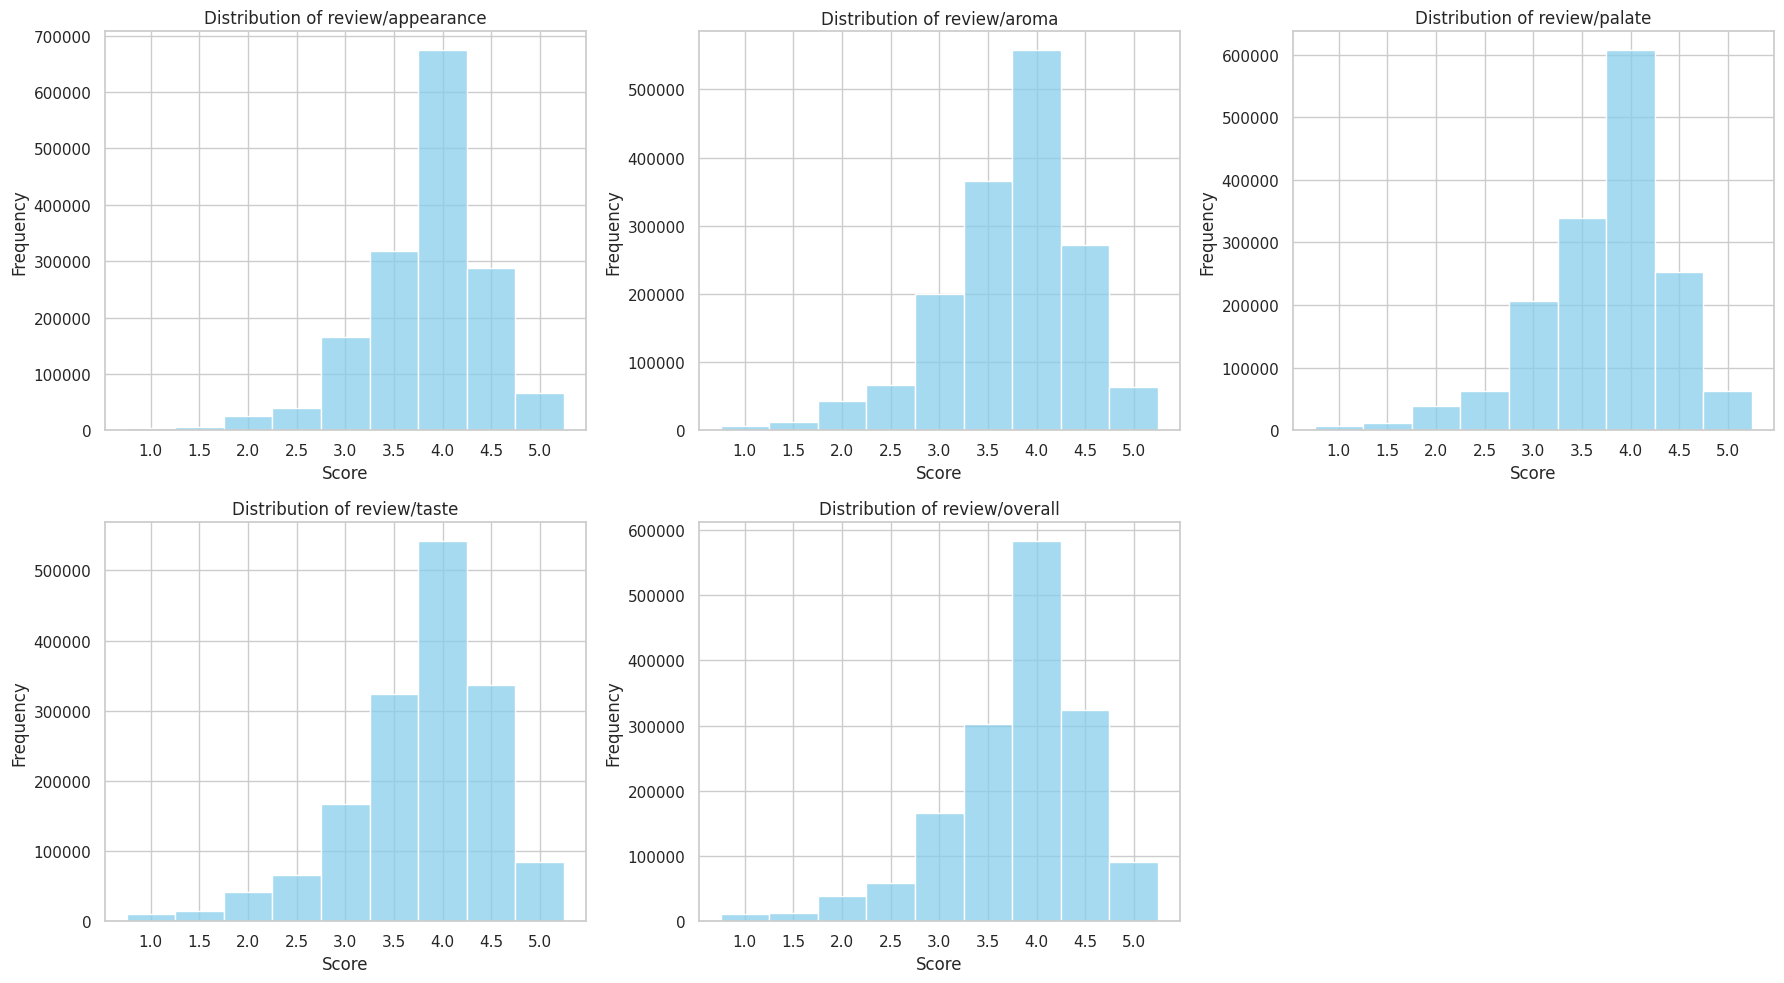

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the style for the plots
sns.set(style="whitegrid")

# List of rating columns to visualize
rating_cols = ['review/appearance', 'review/aroma', 'review/palate', 'review/taste', 'review/overall']

# Create a figure with subplots for ratings
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

# Ratings are typically in increments of 0.5 from 1 to 5
bins = np.arange(1, 6, 0.5) - 0.25

for i, col in enumerate(rating_cols):
    sns.histplot(df[col], bins=np.arange(0.75, 5.75, 0.5), kde=False, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Frequency')
    axes[i].set_xticks(np.arange(1, 5.5, 0.5))

# Remove the empty 6th subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

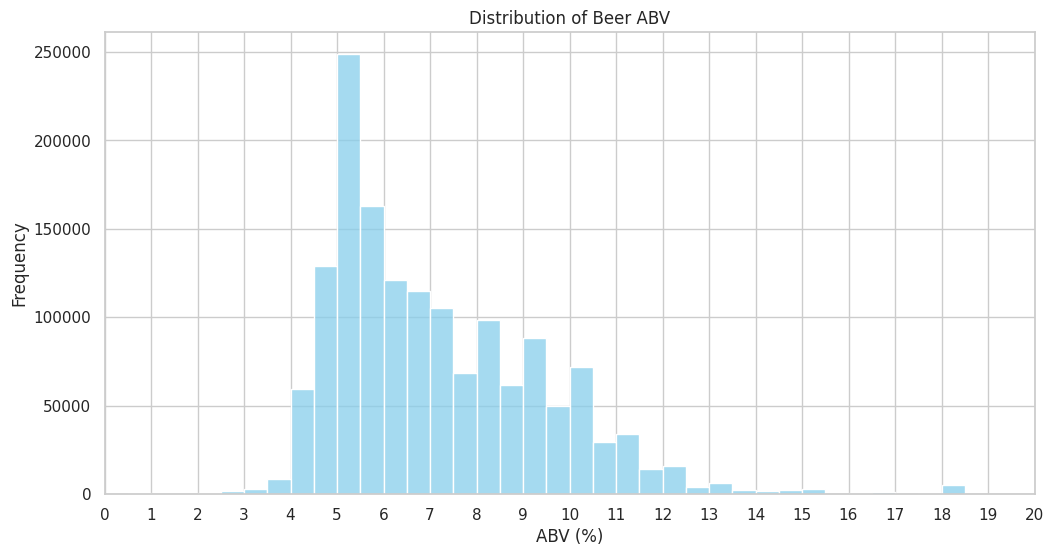

In [ ]:
# Visualize ABV distribution
plt.figure(figsize=(12, 6))

# Convert to numeric, coercing errors to NaN
abv_numeric = pd.to_numeric(df['beer/ABV'], errors='coerce').dropna()

# Defining bins to align with whole numbers/increments
bins = np.arange(0, 21, 0.5)

sns.histplot(abv_numeric, bins=bins, kde=False, color='skyblue')
plt.title('Distribution of Beer ABV')
plt.xlabel('ABV (%)')
plt.ylabel('Frequency')

# Setting x-ticks to show clear increments
plt.xticks(np.arange(0, 21, 1))
plt.xlim(0, 20)
plt.show()

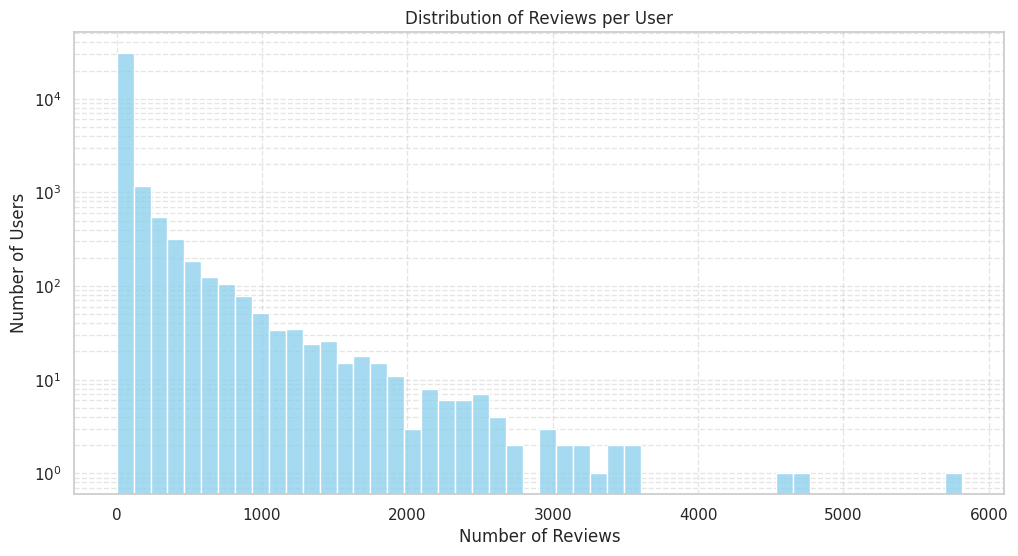

Average reviews per user: 47.52
Median reviews per user: 3.00
Mode of reviews per user: 1.00
Max reviews per user: 5,817


In [ ]:
# Calculate interactions per user
user_counts = df['review/profileName'].value_counts()

plt.figure(figsize=(12, 6))
sns.histplot(user_counts, bins=50, kde=False, color='skyblue')
plt.title('Distribution of Reviews per User')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Users')

# Using log scale for x-axis as interaction counts often follow a long tail
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

print(f"Average reviews per user: {user_counts.mean():.2f}")
print(f"Median reviews per user: {user_counts.median():.2f}")
print(f"Mode of reviews per user: {user_counts.mode()[0]:.2f}")
print(f"Max reviews per user: {user_counts.max():,}")

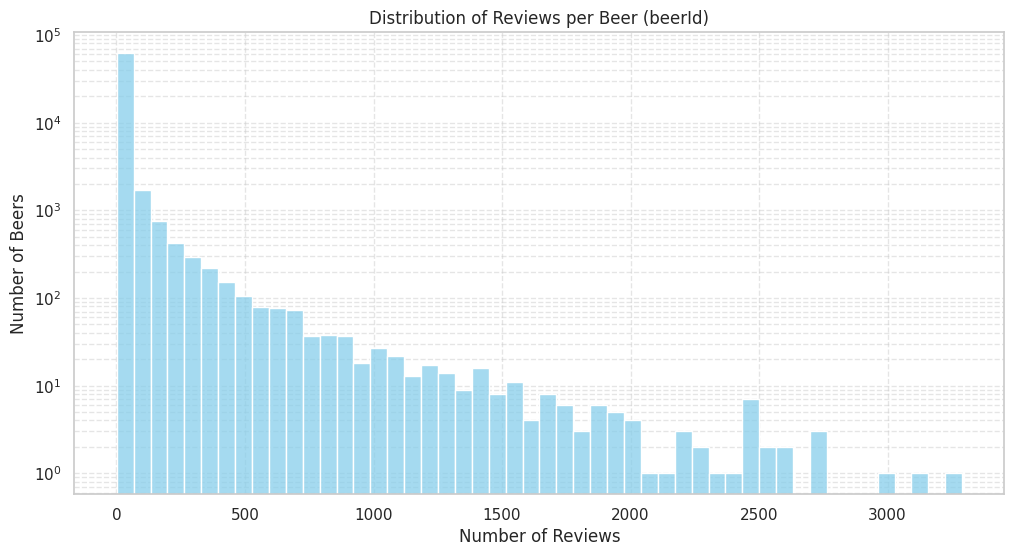

Average reviews per beer: 24.02
Median reviews per beer: 2.00
Max reviews for a single beer: 3,290


In [ ]:
# Calculate interactions per beer
beer_counts = df['beer/beerId'].value_counts()

plt.figure(figsize=(12, 6))
sns.histplot(beer_counts, bins=50, kde=False, color='skyblue')
plt.title('Distribution of Reviews per Beer (beerId)')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Beers')

# Using log scale for y-axis as beer popularity usually follows a power law
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

print(f"Average reviews per beer: {beer_counts.mean():.2f}")
print(f"Median reviews per beer: {beer_counts.median():.2f}")
print(f"Max reviews for a single beer: {beer_counts.max():,}")

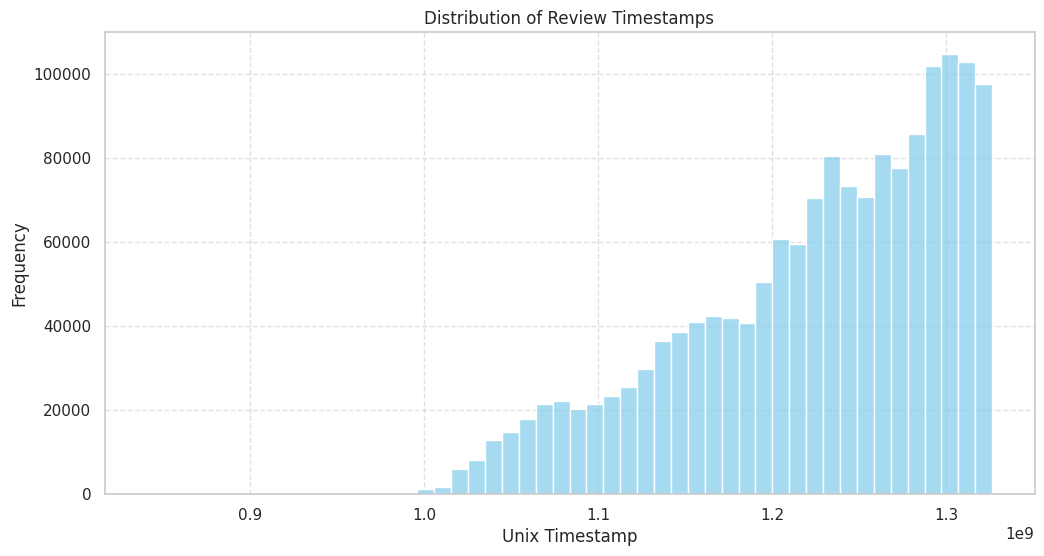

Dataset spans from 1996-08-22 00:00:01 to 2012-01-11 12:35:48


In [ ]:
# Visualize the distribution of review timestamps
plt.figure(figsize=(12, 6))

sns.histplot(df['review/time'], bins=50, kde=False, color='skyblue')
plt.title('Distribution of Review Timestamps')
plt.xlabel('Unix Timestamp')
plt.ylabel('Frequency')

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Optional: Convert min and max to human-readable dates for context
import datetime
min_time = datetime.datetime.fromtimestamp(df['review/time'].min())
max_time = datetime.datetime.fromtimestamp(df['review/time'].max())
print(f"Dataset spans from {min_time} to {max_time}")